<a href="https://colab.research.google.com/github/Carmen10-171/07MIAR_Redes-Neuronales/blob/main/Actividad_C1_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ACTIVIDAD C1-Deep Learning y Deep vision
## MODEL_NAME = "GPT-2"

#### **- Cargando el conjunto de datos**

In [ ]:
# Instalación de librerías
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)


#### **- Celda 2 - Cargar GPT-2**

In [ ]:
MODEL_NAME = "gpt2"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    output_attentions=True
)

model.eval()

print("Modelo cargado correctamente")

C:\Users\ccope\miniconda3\Lib\site-packages\transformers\generation\configuration_utils.py:777: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_attentions` is. When `return_dict_in_generate` is not `True`, `output_attentions` is ignored.
  warnings.warn(


Modelo cargado correctamente


#### **- Celda 3: Model Summary**

In [ ]:
print(model)


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        (attn): GPT2SdpaAttention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)


#### **- Celda 4: Model Summary**

In [ ]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

print(f"Parámetros: {total_params:,}")

Parámetros: 124,439,808


#### **- Celda 5: Número de parámetros**

In [ ]:
text = "The capital of Spain is"

inputs = tokenizer(
    text,
    return_tensors="pt"
)

print(inputs["input_ids"])

tensor([[ 464, 3139,  286, 8602,  318]])


#### **- Celda 6: Forma del tensor de entrada**

In [ ]:
input_ids = inputs["input_ids"]

print("Shape:", input_ids.shape)

Shape: torch.Size([1, 5])


Salida aproximada:

In [ ]:
torch.Size([1,5])

torch.Size([1, 5])

#### **- Celda 7: Distribución del tensor de entrada**


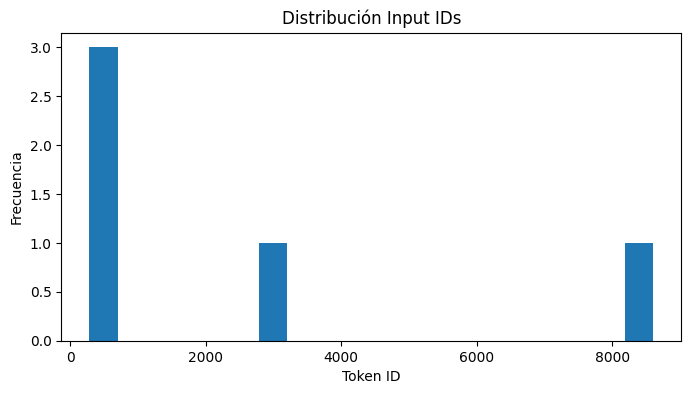

In [ ]:
plt.figure(figsize=(8,4))

plt.hist(
    input_ids.numpy().flatten(),
    bins=20
)

plt.title(
    "Distribución Input IDs"
)

plt.xlabel("Token ID")
plt.ylabel("Frecuencia")

plt.show()

#### **- Celda 8: Obtener logits**

In [ ]:
with torch.no_grad():

    outputs = model(**inputs)

logits = outputs.logits
print(logits.shape)

torch.Size([1, 5, 50257])


Salida aproximada:

In [ ]:
torch.Size([1, 5, 50257])

torch.Size([1, 5, 50257])

#### **- Celda 9: Distribución de logits**

In [ ]:
last_logits = logits[0, -1].cpu().numpy()


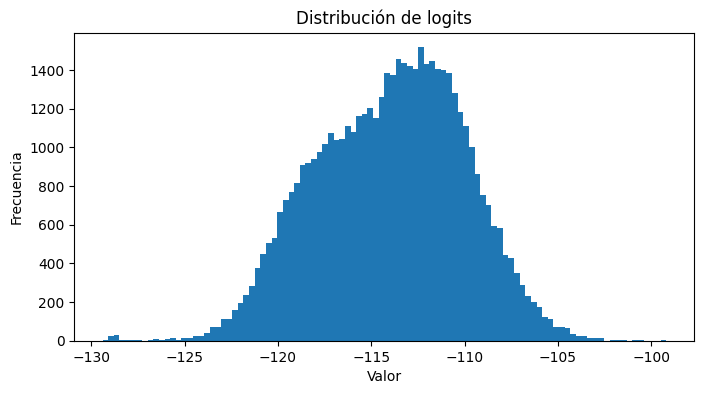

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.hist(last_logits, bins=100)

plt.title("Distribución de logits")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")

plt.show()

#### **- Celda 10: Predicción siguiente token**

In [ ]:
next_token = torch.argmax(logits[0, -1]).item()

print("Token:", next_token)
print(tokenizer.decode([next_token]))

Token: 14708
 Madrid


#### **- Celda 11: Obtener Self-Attention**

In [ ]:
output = model.generate(
    input_ids=inputs["input_ids"],
    max_new_tokens=20,
    do_sample=False
)

generated_text = tokenizer.decode(
    output[0],
    skip_special_tokens=True
)

print(generated_text)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


The capital of Spain is Madrid, and the capital of Spain is Madrid. The capital of Spain is Madrid. The capital of


#### **- Celda 12: Obtener attention weights**

In [ ]:
with torch.no_grad():

    outputs = model(
        **inputs,
        output_attentions=True
    )

attentions = outputs.attentions
print(len(attentions))
print(attentions[0].shape)

12
torch.Size([1, 12, 5, 5])


#### **- Celda 13: Ver dimensiones**

In [ ]:
print(len(attentions))

12


In [ ]:
print(attentions[0].shape)

torch.Size([1, 12, 5, 5])


#### **- Celda 14 - Heatmap ejemplo 1**

In [ ]:
attention_map = (
    attentions[-1][0, 0]
    .cpu()
    .numpy()
)


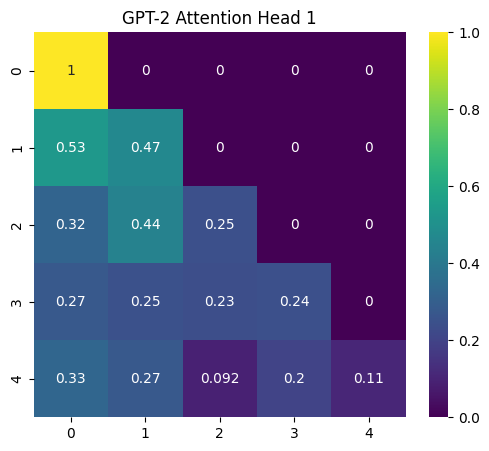

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    attention_map,
    cmap="viridis",
    annot=True
)

plt.title(
    "GPT-2 Attention Head 1"
)

plt.show()

#### **- Celda 15 - Segundo ejemplo**

In [ ]:
text2 = "The Eiffel Tower is located in"

inputs2 = tokenizer(
    text2,
    return_tensors="pt"
)

In [ ]:
with torch.no_grad():

    outputs2 = model(
        **inputs2,
        output_attentions=True
    )

attentions2 = outputs2.attentions
print(type(attentions2))
print(len(attentions2))

<class 'tuple'>
12


In [ ]:
attention_map2 = (
    attentions2[-1][0, 0]
    .cpu()
    .numpy()
)



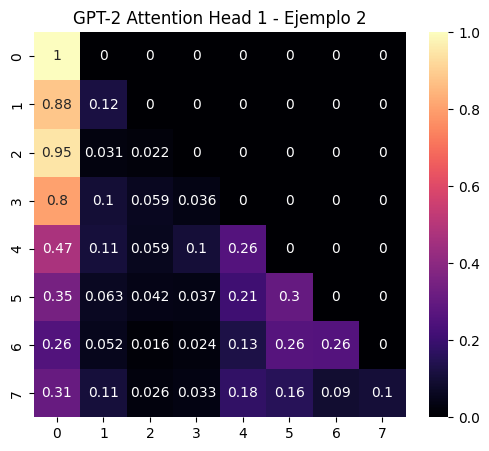

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    attention_map2,
    cmap="magma",
    annot=True
)

plt.title("GPT-2 Attention Head 1 - Ejemplo 2")

plt.savefig(
    "attention_example2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()